# Get quantitative measure from sim3 results version 2

Im the main text, we use 5 edges.

Three layers, 2 edges each regulator, scale-free mRNA and TF, 50+50+50 nodes. 200. Fine-grained constraints.
- "sim3_ggm_three_layer_v2_batch_2024_08_07_22_31_38" Scale 0.8

Three layers, 5 edges each regulator, scale-free mRNA and TF, 50+50+50 nodes. 200. Fine-grained constraints.
- "sim3_ggm_three_layer_v2_batch_2024_08_07_16_41_06" Scale 0.75


In [77]:
import numpy as np
from importlib import reload
import matplotlib.pyplot as plt
from iddn_paper import sim3_read_draw_sim_res as sim3

reload(sim3)

<module 'iddn_paper.sim3_read_draw_sim_res' from '/mnt/dat1/work/network/a_pkg/iddn_paper/src/iddn_paper/sim3_read_draw_sim_res.py'>

In [23]:
node = 5
if node == 5:
    exp_name = "sim3_ggm_three_layer_v2_batch_2024_08_07_16_41_06"
else:
    exp_name = "sim3_ggm_three_layer_v2_batch_2024_08_07_22_31_38"

In [24]:
top_folder = "../../iddn_data/"

In [87]:
import bisect

def get_partial_auc(tpfp_cdn_lst, mthd, proc_thr=0.05):
    fpr_all = tpfp_cdn_lst[mthd][:,0,3][::-1]
    tpr_all = tpfp_cdn_lst[mthd][:,0,2][::-1]
    fpr_thr, tpr_thr = _get_fpr_tpr_for_thresh(fpr_all, tpr_all, proc_thr)
    inds = [i for (i, (s, e)) in enumerate(zip(fpr_thr[: -1], fpr_thr[1: ])) if s != e] + [len(fpr_thr) - 1]
    fpr, tpr = fpr_thr[inds], tpr_thr[inds]
    area = 0
    n = len(fpr)
    for i in range(n-1):
        x0 = fpr[i+1] - fpr[i]
        y0 = tpr[i]
        area += x0*y0
    print(area/proc_thr)

def _get_fpr_tpr_for_thresh(fpr, tpr, thresh):
    p = bisect.bisect_left(fpr, thresh)
    fpr = fpr.copy()
    fpr[p] = thresh
    return fpr[: p + 1], tpr[: p + 1]

## P1: Compare iDDN, JGL, and iDINGO

In [26]:
p1_comm_iddn, p1_diff_iddn, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=6, msk_level_in=6, mrna_only=False, method='iddn', top_folder=top_folder, top_folder_R=top_folder)
p1_comm_jgl, p1_diff_jgl, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=6, mrna_only=False, method='jgl', top_folder=top_folder, top_folder_R=top_folder)
p1_comm_idingo, p1_diff_idingo, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=6, mrna_only=False, method='idingo', top_folder=top_folder, top_folder_R=top_folder)


['dep_est']
(32, 40, 16, 2, 150, 150)
['dep_est']
(32, 40, 17, 2, 150, 150)
['R1', 'R2', 'diffscore']
(5, 150, 150)
['R1', 'R2', 'diffscore']
(5, 150, 150)
['R1', 'R2', 'diffscore']
(5, 150, 150)


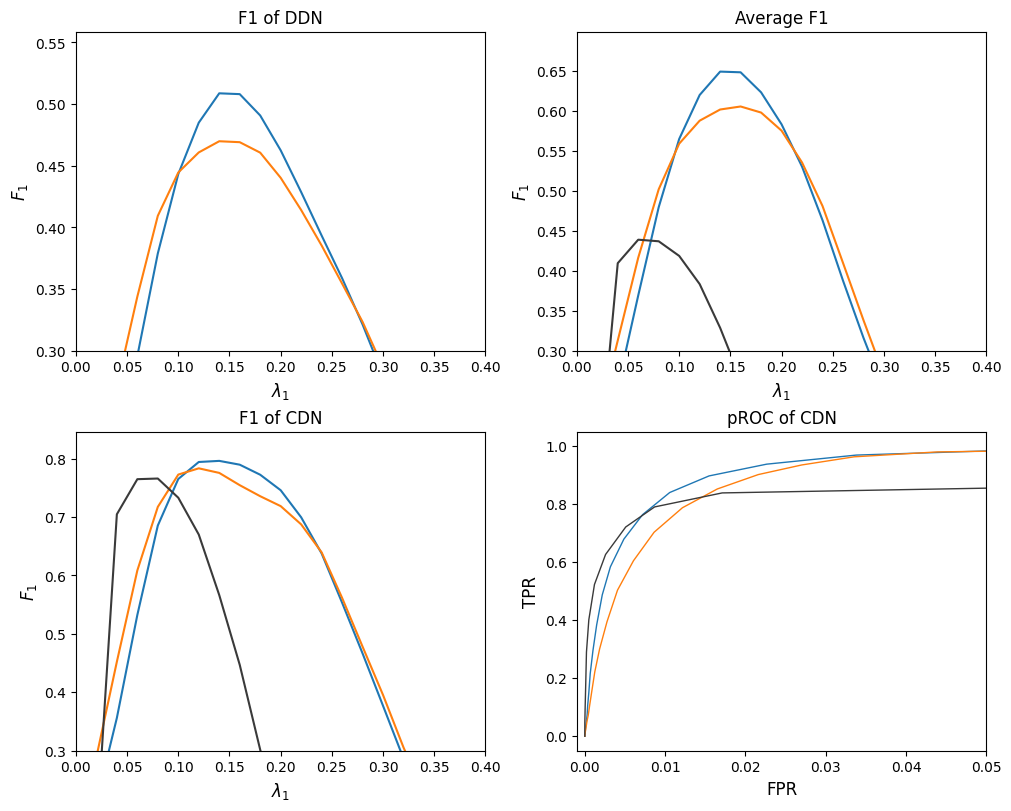

In [27]:
xrange = np.arange(0.02, 0.81, 0.02)
if node==2:
    xlim = [-0.0002, 0.005]
else:
    xlim = [-0.001, 0.05]
fig, res = sim3.draw_F1_pROC_curves_for_methods(
    # [p1_comm_iddn, p1_comm_jgl],
    [p1_comm_iddn, p1_comm_jgl, p1_comm_idingo],
    # [p1_diff_iddn, p1_diff_jgl],
    [p1_diff_iddn, p1_diff_jgl, p1_diff_idingo],
    xlim=xlim,
    xlim_1d=[0, 0.4],
    ylim_1d=[0.3, 1.0],
    xrange=xrange,
)
# fig.savefig(f"./temp/node_{node}_compare.png")

In [102]:
tpfp_cdn_lst = res[0]
for i in range(3):
    get_partial_auc(tpfp_cdn_lst, i, 0.05)
for i in range(3):
    print(np.max(res[2][i]))

0.8578384269072189
0.8158629098839426
0.7905911075454874
0.5087863662680883
0.4699105799116118
0.1144196227607108


## P2: iDDN vs. DDN, benefits of constraints

In [103]:
p2_comm_iddn3, p2_diff_iddn3, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=0, msk_level_in=3, mrna_only=False, method='iddn',top_folder=top_folder)
p2_comm_iddn7, p2_diff_iddn7, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=0, msk_level_in=6, mrna_only=False, method='iddn',top_folder=top_folder)
p2_comm_iddn10, p2_diff_iddn10, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=0, msk_level_in=9, mrna_only=False, method='iddn',top_folder=top_folder)
p2_comm_ddn, p2_diff_ddn, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=0, mrna_only=False, method='ddn',top_folder=top_folder)


['dep_est']
(32, 40, 16, 2, 150, 150)
['dep_est']
(32, 40, 16, 2, 150, 150)
['dep_est']
(32, 40, 16, 2, 150, 150)
['dep_est']
(32, 40, 16, 2, 150, 150)


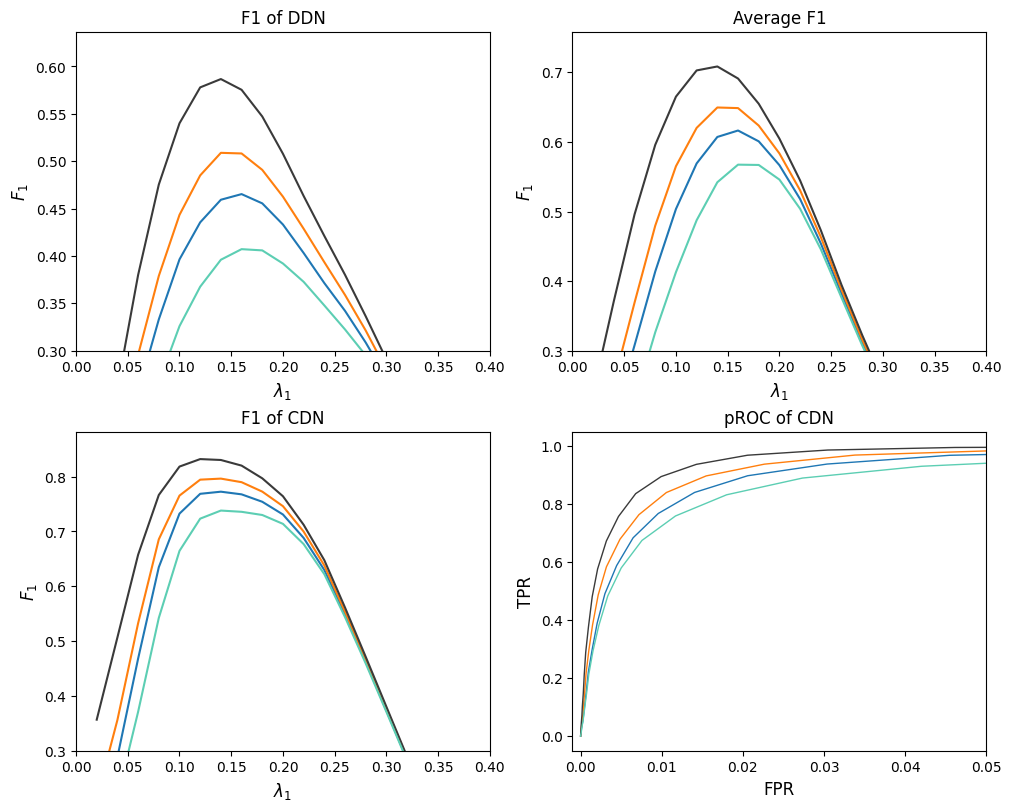

In [104]:
xrange = np.arange(0.02, 0.81, 0.02)
if node==2:
    xlim = [-0.0002, 0.0025]
else:
    xlim = [-0.001, 0.05]
fig, res = sim3.draw_F1_pROC_curves_for_methods(
    [p2_comm_iddn3, p2_comm_iddn7, p2_comm_iddn10, p2_comm_ddn],
    [p2_diff_iddn3, p2_diff_iddn7, p2_diff_iddn10, p2_diff_ddn],
    xlim=xlim,
    xlim_1d=[0, 0.4],
    ylim_1d=[0.3, 1.0],
    xrange=xrange,
)
# fig.savefig(f"./temp/node_{node}_iddn_ddn_constraints_basic.png")

In [105]:
tpfp_cdn_lst = res[0]
for i in range(4):
    get_partial_auc(tpfp_cdn_lst, i, 0.05)
for i in range(4):
    print(np.max(res[2][i]))

0.8208475275476276
0.8578384269072189
0.9043253678999509
0.7791327200924587
0.46524032905019413
0.5087863662680883
0.586622692552996
0.4071594501306008


## P3: JGL + post vs. JGL, benefits of constraints

In [17]:
p3_comm_iddn, p3_diff_iddn, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=6, msk_level_in=6, mrna_only=False, method='iddn')
p3_comm_jgl, p3_diff_jgl, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=0, mrna_only=False, method='jgl')
p3_comm_jgl_c, p3_diff_jgl_c, _, _ = sim3.read_one_res(exp_name, n_sample=200, msk_level=6, mrna_only=False, method='jgl')

['dep_est']
(32, 40, 16, 2, 150, 150)
['dep_est']
(32, 40, 17, 2, 150, 150)
['dep_est']
(32, 40, 17, 2, 150, 150)


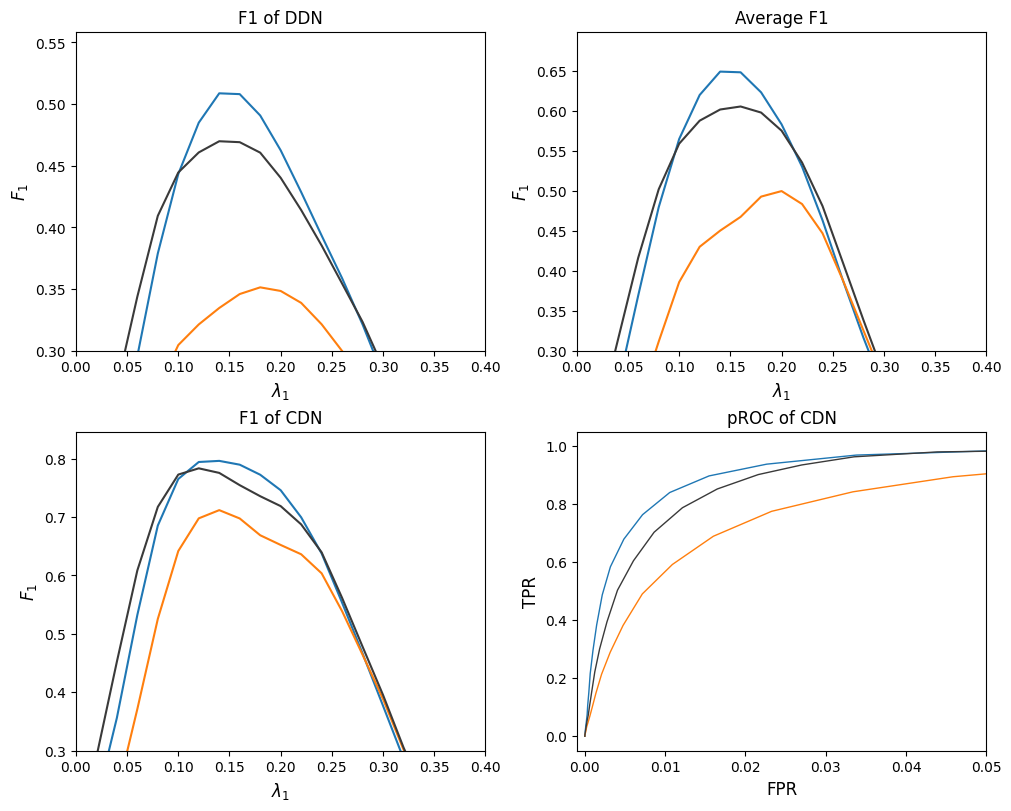

In [ ]:
xrange = np.arange(0.02, 0.81, 0.02)
if node==2:
    xlim = [-0.0002, 0.005]
else:
    xlim = [-0.001, 0.05]
fig = sim3.draw_F1_pROC_curves_for_methods(
    [p3_comm_iddn, p3_comm_jgl, p3_comm_jgl_c],
    [p3_diff_iddn, p3_diff_jgl, p3_diff_jgl_c],
    xlim=xlim,
    xlim_1d=[0, 0.4],
    ylim_1d=[0.3, 1.0],
    xrange=xrange,
)
# fig.savefig(f"./temp/node_{node}_iddn_jgl_constraints_basic.png")

## P4: mRNA vs. mRNA + others, iDDN without constraints, benefits of multi-omics

In [106]:
n_sample = 200
p4_comm_iddn0, p4_diff_iddn0, _, _ = sim3.read_one_res(exp_name, n_sample=n_sample, msk_level=0, msk_level_in=0, mrna_only=True, method='iddn', subset='mrna', top_folder=top_folder)
p4_comm_iddn1, p4_diff_iddn1, _, _ = sim3.read_one_res(exp_name, n_sample=n_sample, msk_level=0, msk_level_in=0, mrna_only=True, method='iddn', subset='mrna_tf', top_folder=top_folder)
p4_comm_iddn2, p4_diff_iddn2, _, _ = sim3.read_one_res(exp_name, n_sample=n_sample, msk_level=0, msk_level_in=0, mrna_only=True, method='iddn', subset='mrna_mirna', top_folder=top_folder)
p4_comm_iddn3, p4_diff_iddn3, _, _ = sim3.read_one_res(exp_name, n_sample=n_sample, msk_level=0, msk_level_in=0, mrna_only=True, method='iddn', subset='mrna_tf_mirna', top_folder=top_folder)

['dep_est']
(32, 40, 11, 2, 150, 150)
['dep_est']
(32, 40, 11, 2, 150, 150)
['dep_est']
(32, 40, 11, 2, 150, 150)
['dep_est']
(32, 40, 11, 2, 150, 150)


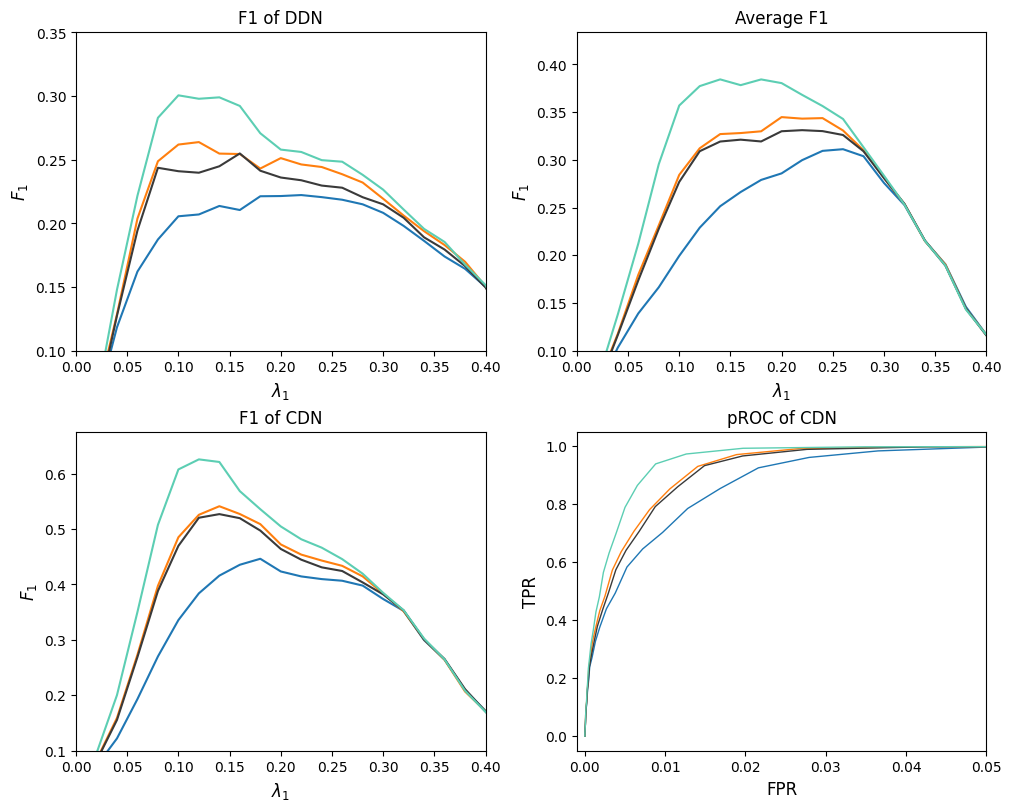

In [107]:
xrange = np.arange(0.02, 0.81, 0.02)
if node==2:
    xlim = [-0.00005, 0.0005]
else:
    xlim = [-0.001, 0.05]
fig, res = sim3.draw_F1_pROC_curves_for_methods(
    [p4_comm_iddn0, p4_comm_iddn1, p4_comm_iddn2, p4_comm_iddn3],
    [p4_diff_iddn0, p4_diff_iddn1, p4_diff_iddn2, p4_diff_iddn3],
    xlim=xlim,
    xlim_1d=[0, 0.4],
    ylim_1d=[0.1, 1.0],
    xrange=xrange,
)
# fig.savefig(f"./temp/node_{node}_iddn_subsets_n_{n_sample}.png")

In [108]:
tpfp_cdn_lst = res[0]
for i in range(4):
    get_partial_auc(tpfp_cdn_lst, i, 0.05)
for i in range(4):
    print(np.max(res[2][i]))

0.8298805620863833
0.8881214447410405
0.879602107684201
0.9259786389832394
0.222249432024438
0.2638438461569621
0.25491782751755254
0.3005673928891176
